In [1]:
from scipy.io import wavfile
import numpy as np
from ml_tools.utilities import rolling_windows_nd, standardize_data
from ml_tools.models.layers.operators import LatentStack
from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD
from ml_tools.models.layers.layers import (
    FrequencyFFT,
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
)

from ml_tools.models.blocks import (
    FourierAttention,
    SpectreAttention)

from ml_tools.models.embedding.positional import RopeEmbedding
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

MAX_POSSIBLE_WINDOWS = 2000
WINDOW_MS = 100


In [2]:
def read_and_process_datafile(filename: str) -> tuple[list[np.ndarray], int]:

    sample_rate, waveform = wavfile.read(filename)
    time_per_sample = 1000 / sample_rate
    print(time_per_sample, WINDOW_MS, (WINDOW_MS / time_per_sample))
    SAMPLES_PER_WINDOW = int(WINDOW_MS / time_per_sample)
    print(waveform.shape, SAMPLES_PER_WINDOW)
    # Mono recoridng---
    if waveform.ndim == 1:
        waveform = waveform.reshape(-1, 1)
        # target = waveform.reshape(-1, 1)
        target = standardize_data(waveform)

        try:
            windowed_data_l = rolling_windows_nd(
                data=target,
                window_size=SAMPLES_PER_WINDOW,
                num_overlap=SAMPLES_PER_WINDOW // 5,
                axis=0,
            )
        except TypeError:
            return [], SAMPLES_PER_WINDOW

        return [windowed_data_l], SAMPLES_PER_WINDOW

    # stereo recording---
    else:
        waveform_l, waveform_r = (
            standardize_data(waveform[:, 0], axis=-1),
            standardize_data(waveform[:, 1], axis=-1),
        )

        windowed_data_l = rolling_windows_nd(
            data=waveform_l,
            window_size=SAMPLES_PER_WINDOW,
            num_overlap=SAMPLES_PER_WINDOW // 5,
            axis=0,
        )

        windowed_data_r = rolling_windows_nd(
            data=waveform_r,
            window_size=SAMPLES_PER_WINDOW,
            num_overlap=SAMPLES_PER_WINDOW // 5,
            axis=0,
        )

        return [windowed_data_l, windowed_data_r], SAMPLES_PER_WINDOW

In [3]:
%pdb on
import os
import pickle

all_windowed_data = []

all_filenames = os.listdir(f"../data/")
for fn in all_filenames:
    if fn.endswith(".wav"):
        list_of_array, SAMPLES_PER_WINDOW = read_and_process_datafile(
            f"../data/{fn}")
    else:
        continue

    # all_windowed_data.append({fn: array})
    # filenames too long
    if list_of_array:
        all_windowed_data.extend(list_of_array)

with open(f"../data/windowed_data.pkl", "wb") as f:
    pickle.dump(all_windowed_data, f)


Automatic pdb calling has been turned ON
0.25 100 400.0
(18373,) 400
0.25 100 400.0
(25326,) 400
0.25 100 400.0
(28761,) 400
0.25 100 400.0
(23005,) 400
0.25 100 400.0
(17200,) 400
0.25 100 400.0
(17569,) 400
0.25 100 400.0
(29947,) 400
0.25 100 400.0
(14085,) 400
0.25 100 400.0
(25750,) 400
0.25 100 400.0
(27208,) 400
0.25 100 400.0
(18123,) 400
0.25 100 400.0
(28123,) 400
0.25 100 400.0
(25716,) 400
0.25 100 400.0
(20808,) 400
0.25 100 400.0
(30264,) 400
0.25 100 400.0
(27403,) 400
0.25 100 400.0
(22025,) 400
0.25 100 400.0
(35065,) 400
0.25 100 400.0
(20978,) 400
0.25 100 400.0
(29049,) 400
0.25 100 400.0
(31574,) 400
0.25 100 400.0
(23701,) 400
0.25 100 400.0
(18705,) 400
0.25 100 400.0
(21017,) 400
0.25 100 400.0
(22458,) 400
0.25 100 400.0
(23283,) 400
0.25 100 400.0
(27546,) 400
0.25 100 400.0
(31364,) 400
0.25 100 400.0
(29017,) 400
0.25 100 400.0
(27582,) 400
0.25 100 400.0
(19430,) 400
0.25 100 400.0
(20743,) 400
0.25 100 400.0
(26652,) 400
0.25 100 400.0
(30587,) 400
0.25 10

In [4]:
print(SAMPLES_PER_WINDOW)

400


In [5]:
len(all_windowed_data)

3752

In [6]:
all_reshaped_data = []
for arr in all_windowed_data:
    print(arr.shape)
    all_reshaped_data.append(np.moveaxis(arr, source=-1, destination=0))

(57, 400, 1)
(78, 400, 1)
(89, 400, 1)
(71, 400, 1)
(53, 400, 1)
(54, 400, 1)
(93, 400, 1)
(43, 400, 1)
(80, 400, 1)
(84, 400, 1)
(56, 400, 1)
(87, 400, 1)
(80, 400, 1)
(64, 400, 1)
(94, 400, 1)
(85, 400, 1)
(68, 400, 1)
(109, 400, 1)
(65, 400, 1)
(90, 400, 1)
(98, 400, 1)
(73, 400, 1)
(58, 400, 1)
(65, 400, 1)
(69, 400, 1)
(72, 400, 1)
(85, 400, 1)
(97, 400, 1)
(90, 400, 1)
(85, 400, 1)
(60, 400, 1)
(64, 400, 1)
(83, 400, 1)
(95, 400, 1)
(63, 400, 1)
(82, 400, 1)
(67, 400, 1)
(57, 400, 1)
(64, 400, 1)
(49, 400, 1)
(70, 400, 1)
(75, 400, 1)
(69, 400, 1)
(70, 400, 1)
(44, 400, 1)
(92, 400, 1)
(71, 400, 1)
(89, 400, 1)
(67, 400, 1)
(74, 400, 1)
(87, 400, 1)
(68, 400, 1)
(80, 400, 1)
(47, 400, 1)
(84, 400, 1)
(90, 400, 1)
(97, 400, 1)
(78, 400, 1)
(82, 400, 1)
(67, 400, 1)
(43, 400, 1)
(46, 400, 1)
(94, 400, 1)
(55, 400, 1)
(66, 400, 1)
(66, 400, 1)
(110, 400, 1)
(75, 400, 1)
(1172, 400, 1)
(90, 400, 1)
(82, 400, 1)
(40, 400, 1)
(114, 400, 1)
(82, 400, 1)
(59, 400, 1)
(53, 400, 1)
(99, 40

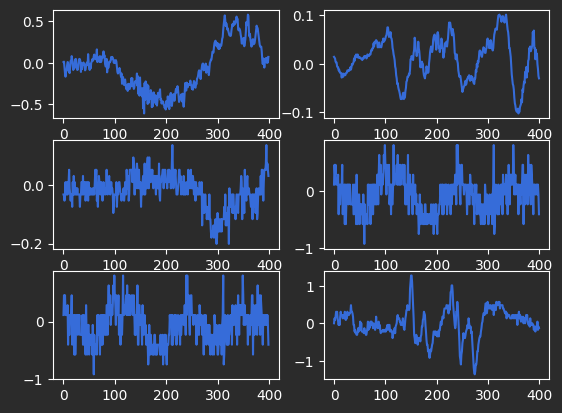

In [7]:
plt.figure()
for idxx, idx in enumerate(RNG.integers(0, 100, 6)):
    t = all_reshaped_data[idx]
    plt.subplot(3,2, idxx + 1)
    plt.plot(t[:, 3, ...].reshape(-1))

plt.show()

In [8]:
del(all_windowed_data)

In [9]:
#  FFT will output a shape of n//2 + 1.
real_positive_fft_shape = (SAMPLES_PER_WINDOW // 2) + 1
max_positive_fft_shape = (MAX_POSSIBLE_WINDOWS // 2) + 1

# project dimensions down to half - this should be enough to keep our calculations
# limited without losing too much grainularity in the data.
# LATENT_DIMENSION = int(real_positive_fft_shape * 0.75)
LATENT_DIMENSION = 512

# AMPLITUDE ------------------------------------------------------------------
# FUNNEL PROJECTION -->
# dimensional reduction in Feed Forward, built of 1-4 stacked layers
# this gives us a weighted amplitude
# Project down to real_positive_fft_shape? OR LATENT_DIMENSION
# (1920, 1080,   real_positive_fft_shape)
amplitude_layer_a = FullyConnectedLayer(
    ni=SAMPLES_PER_WINDOW, no=1200, activation_type="relu", is_output=False
)
amplitude_layer_b = FullyConnectedLayer(
    ni=1200, no=real_positive_fft_shape, activation_type="relu",
    is_output=False
)
amplitude_layer_c = FullyConnectedLayer(
    ni=real_positive_fft_shape,
    no=LATENT_DIMENSION,
    activation_type="tanh",
    is_output=True,
)


# FREQUENCY -----------------------------------------------------------------
# real positive only FFT: np rfft process -> final shape of FFT transform is  n//2 + 1.
# transformed_data = np.fft.rfft(windowed_data, axis=-1)
freq_fft_layer = FrequencyFFT(
    max_sequence_length=MAX_POSSIBLE_WINDOWS + 1,
    window_size=SAMPLES_PER_WINDOW
)
freq_fc_layer = FullyConnectedLayer(
    ni=real_positive_fft_shape,
    no=LATENT_DIMENSION,
    activation_type="tanh",
    is_output=True,
)

# Feed Forward, built of 1-3 stacked layers?
stacking_layer = LatentStack()

# Rotary Positional embedding - (relative position and distances -------------
rope_layer = RopeEmbedding(
    sequence_length=MAX_POSSIBLE_WINDOWS, embedding_dimension=2 * LATENT_DIMENSION
)

enc_attention = SpectreAttention(MAX_POSSIBLE_WINDOWS, hidden_dim=2 * LATENT_DIMENSION)

# enc_attention = SpectreAttention(
#     sequence_length=MAX_POSSIBLE_WINDOWS,
#     hidden_dim=2 * LATENT_DIMENSION
# )


EMBEDDING_DIM = 512
# feed froward--
FC_IN = 2 * LATENT_DIMENSION
dropout_a = DropoutLayer(dropout_prob=0.05)
fc_a = FullyConnectedLayer(ni=FC_IN, no=1200, activation_type="relu",
                           is_output=False)
fc_b = FullyConnectedLayer(ni=1200, no=900, activation_type="relu",
                           is_output=False)
fc_c = FullyConnectedLayer(
    ni=900, no=EMBEDDING_DIM, activation_type="tanh", is_output=False
)


# And Finally, we're at the latent space embedding ------------------------
# NOW WE CAN SEND THE LATENT EMBEDDING INTO our Kernel FourierNetwork.
# the feature encoding and Kernel FourierNetwork layers out into the model's
# embedding; the latent space.

decoder_dropout = DropoutLayer(dropout_prob=0.05)
# decoder_attention = FourierAttention(ni=EMBEDDING_DIM, no=EMBEDDING_DIM, use_2d=True)

decoder_attention = SpectreAttention(
    sequence_length=MAX_POSSIBLE_WINDOWS,
    hidden_dim=LATENT_DIMENSION
)

decoder_fc_a = FullyConnectedLayer(
    ni=EMBEDDING_DIM, no=1200, activation_type="relu", is_output=False
)
decoder_fc_b = FullyConnectedLayer(
    ni=1200, no=SAMPLES_PER_WINDOW, activation_type="relu", is_output=False
)
decoder_norm = NormalizeLayer(ni=SAMPLES_PER_WINDOW, shift_scale=True)

# rescaling layer
decoder_fc_c = FullyConnectedLayer(
    ni=SAMPLES_PER_WINDOW,
    no=SAMPLES_PER_WINDOW,
    activation_type="linear",
    is_output=True,
)

loss = MSELoss()
optimizer = SGD(0.02)
# assert (decoder_output.shape == (num_windows, samples_per_window))
# REBUILD windowed_data
# reconstruction error = winodw_data - decoder output


# now let's do some fitting ---
all_losses = []
all_layers = [amplitude_layer_a, amplitude_layer_b, amplitude_layer_c, freq_fft_layer, freq_fc_layer,
              stacking_layer, rope_layer, enc_attention, dropout_a, fc_a, fc_b, fc_c, decoder_dropout,
              decoder_attention, decoder_fc_a, decoder_fc_b, decoder_norm, decoder_fc_c,]

In [10]:
%pdb on

Automatic pdb calling has been turned ON


In [11]:
print(real_positive_fft_shape, LATENT_DIMENSION, FC_IN)

201 512 1024


In [12]:
all_reshaped_data[11].shape

(1, 87, 400)

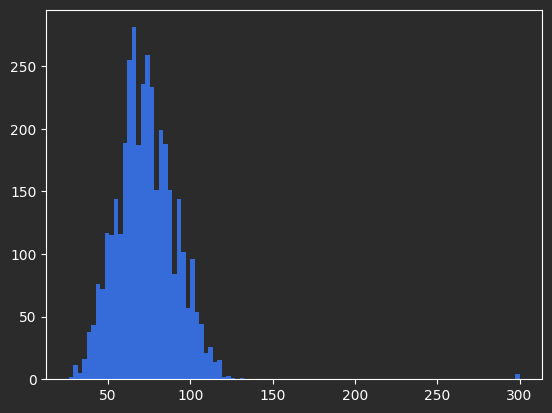

In [13]:
shapes = []
RNG.shuffle(all_reshaped_data)

for windowed_data in all_reshaped_data:
    shapes.append(windowed_data.shape[1])

plt.hist(np.clip(shapes, min=0, max=300), bins=100)
plt.show()

# Training ----


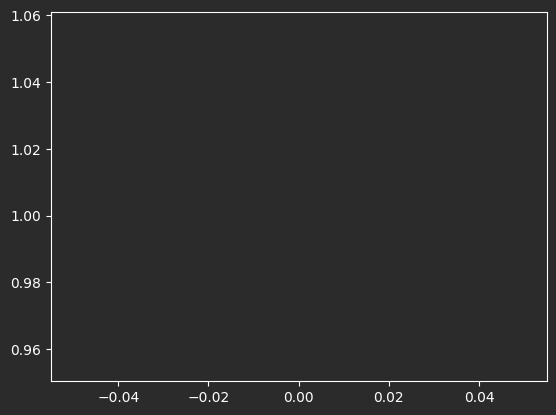

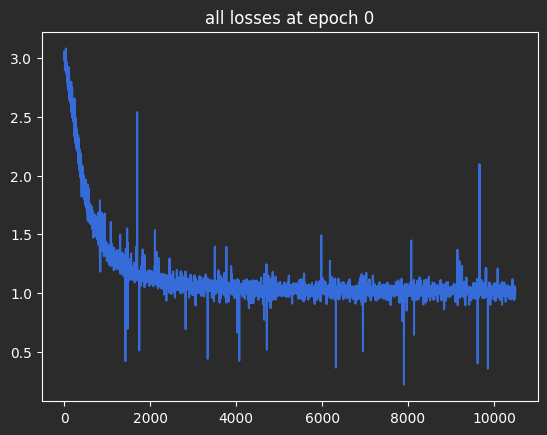

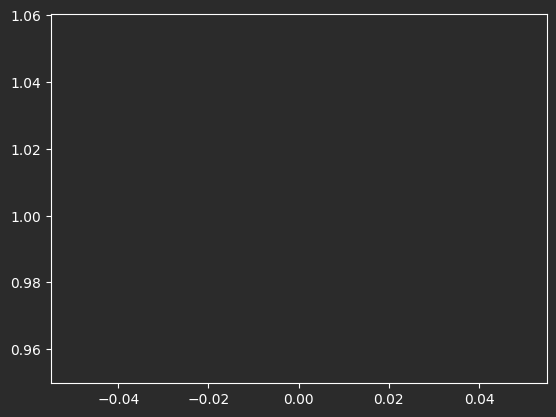

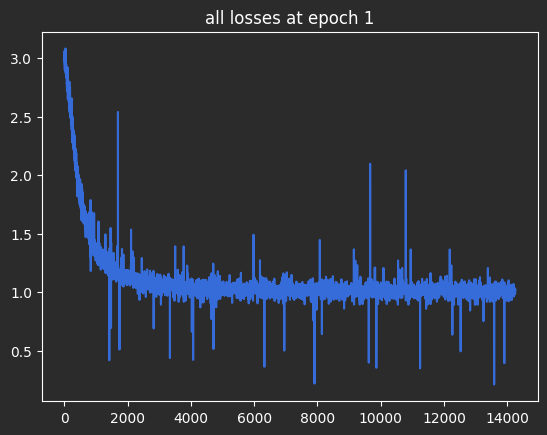

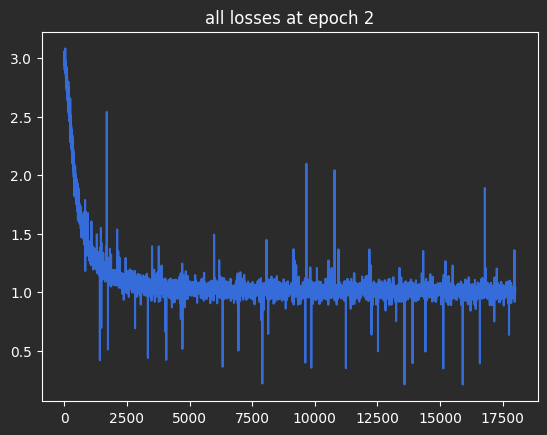

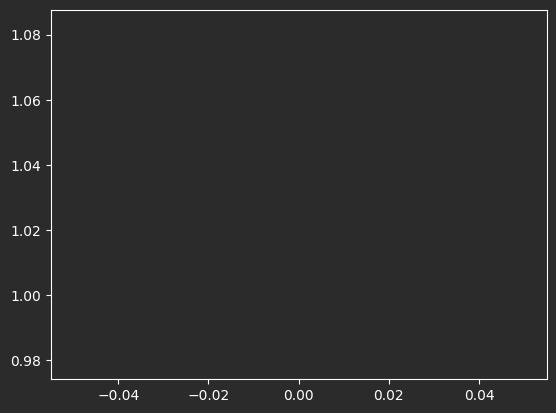

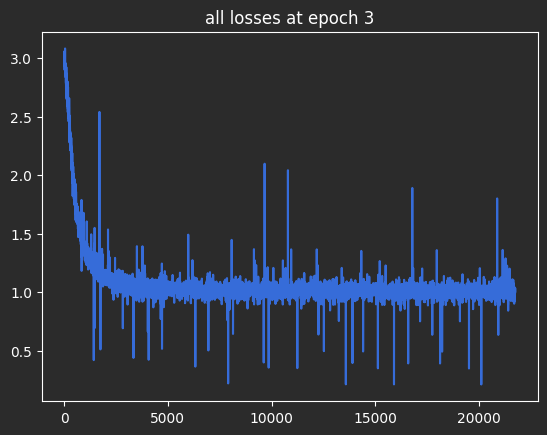

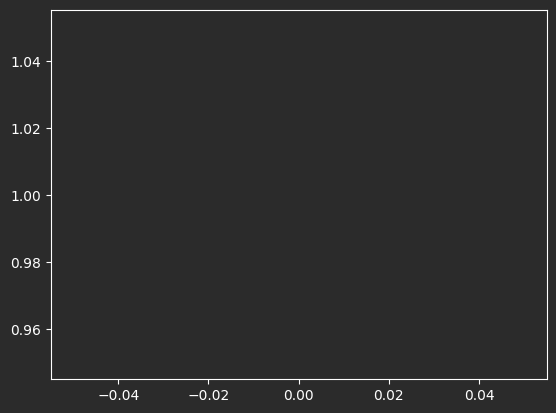

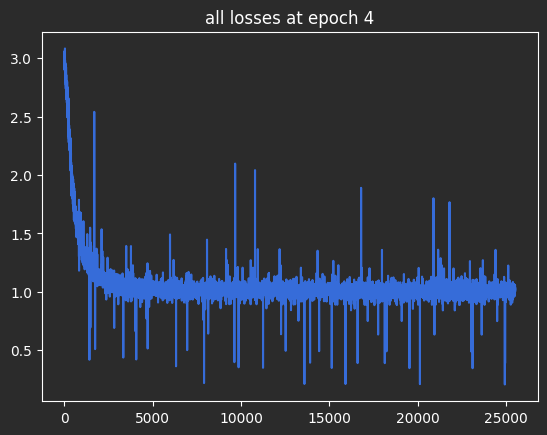

In [24]:

for ep in range(0, 5):
    RNG.shuffle(all_reshaped_data)

    for windowed_data in all_reshaped_data:
        n,m,d = windowed_data.shape
        windowed_data[:, :MAX_POSSIBLE_WINDOWS, :]
        # print(windowed_data.shape)

        # safety check---------
        windowed_data = windowed_data[:, :MAX_POSSIBLE_WINDOWS, :]
        this_stage_loss = []
        for step in range(1):

            # verbose = True if (step + 1) % 3 == 0 else False
            verbose = False

            # -------------------- FORWARD PASS THROUGH THE NETWORK ------------
            x_amp = amplitude_layer_c(amplitude_layer_b(amplitude_layer_a(windowed_data)))
            x_freq = freq_fc_layer(freq_fft_layer(windowed_data))

            if verbose:
                print(f"amp shape:  {x_amp.shape} freq shape: {x_freq.shape}")
            stacked = stacking_layer(x_amp, x_freq)
            if verbose:
                print(f"stacked shape:  {stacked.shape}")
            x_stacked = rope_layer(stacked)
            if verbose:
                print(f"Rope shape:  {x_stacked.shape}")

            encoded = fc_c(fc_b(fc_a(dropout_a(enc_attention(x_stacked)))))
            if verbose:
                print("latent encoding is shape: ", encoded.shape)

            x_prime = decoder_fc_c(
                decoder_norm(
                    decoder_fc_b(
                        decoder_fc_a(
                            decoder_attention(
                                decoder_dropout(encoded))))
                )
            )
            if verbose:
                print("x_output is", x_prime.shape)

            _l = loss.forward(prediction=x_prime, targets=windowed_data)

            this_stage_loss.append(_l.item())
            all_losses.append(_l.item())

            if verbose:
                print(f"x prime shape: {x_prime.shape}")
                print(
                    f"at this stage, we've output a model recreation of encoder-decoder process."
                    f" x_prime (model output) is {x_prime.shape} compared to the original {windowed_data.shape}"
                )
                print(f"reconstruction loss is at {_l}")

                # to_plot = x_prime[0, idx, :].copy().reshape(-1, 1920)
                # to_plot = np.fft.rfft(to_plot)
                # to_plot[:, 1:-1] = to_plot[:, 1:-1] ** 2
                # ys = windowed_data[0, idx, :].copy().reshape(-1, 1920)
                # ys = np.fft.rfft(ys)
                # ys[:, 1:-1] = ys[:, 1:-1] ** 2
                # plt.subplot(1,2,1)
                # plt.plot(freqs, standardize_data(to_plot.squeeze()), color="blue")
                # plt.subplot(1,2,2)
                # plt.plot(freqs, standardize_data(ys.squeeze()), color="yellow")
                # plt.xlabel("Frequency (Hz)")
                # plt.ylabel("power")
                # plt.title("RFFT Power Spectrum")
                # plt.show()
            # -------------------- backwards pass --------------------
            grad_output = loss.backward()

            grad_output = decoder_dropout.backward(
                decoder_attention.backward(
                    decoder_fc_a.backward(
                        decoder_fc_b.backward(
                            decoder_norm.backward(
                                decoder_fc_c.backward(grad_output)
                            )
                        )
                    )
                )
            )
            if verbose:
                print(f"decoder_net backpass {grad_output.shape}")

            grad_output = enc_attention.backward(
                dropout_a.backward(
                    fc_a.backward(
                        fc_b.backward(
                            fc_c.backward(grad_output)
                        )
                    )
                )
            )
            if verbose:
                print(f"embedding_net backpass {grad_output.shape}")
            grad_output = rope_layer.backward(grad_output)
            if verbose:
                print(f"rope_layer backpass {grad_output.shape}")
            amp_grad, freq_grad = stacking_layer.backward(grad_output)
            if verbose:
                print(f"stacking backpass {amp_grad.shape}, freq_grad.shape")

            amp_grad = amplitude_layer_c.backward(amp_grad)
            amp_grad = amplitude_layer_b.backward(amp_grad)
            amp_grad = amplitude_layer_a.backward(amp_grad)
            freq_out = freq_fft_layer.backward(freq_fc_layer.backward(freq_grad))

            optimizer.step(all_layers)

            # plt.plot(x_prime[:, 5].reshape(-1))
            # plt.plot(windowed_data[:, 5].reshape(-1))
            # plt.show()

        # if verbose:
        if False:
            plt.plot(this_stage_loss)
            plt.show()

            plt.plot(x_prime[:, 5].reshape(-1))
            plt.plot(windowed_data[:, 5].reshape(-1))
            plt.show()

        if RNG.random() > 0.9999:
            plt.plot(this_stage_loss)
            plt.show()

    plt.title(f"all losses at epoch {ep}")
    plt.plot(all_losses)
    plt.show()

amp shape:  (1, 64, 512) freq shape: (1, 64, 512)
stacked shape:  (1, 64, 1024)
Rope shape:  (1, 64, 1024)
latent encoding is shape:  (1, 64, 512)
(1, 64, 400) (1, 64, 400)


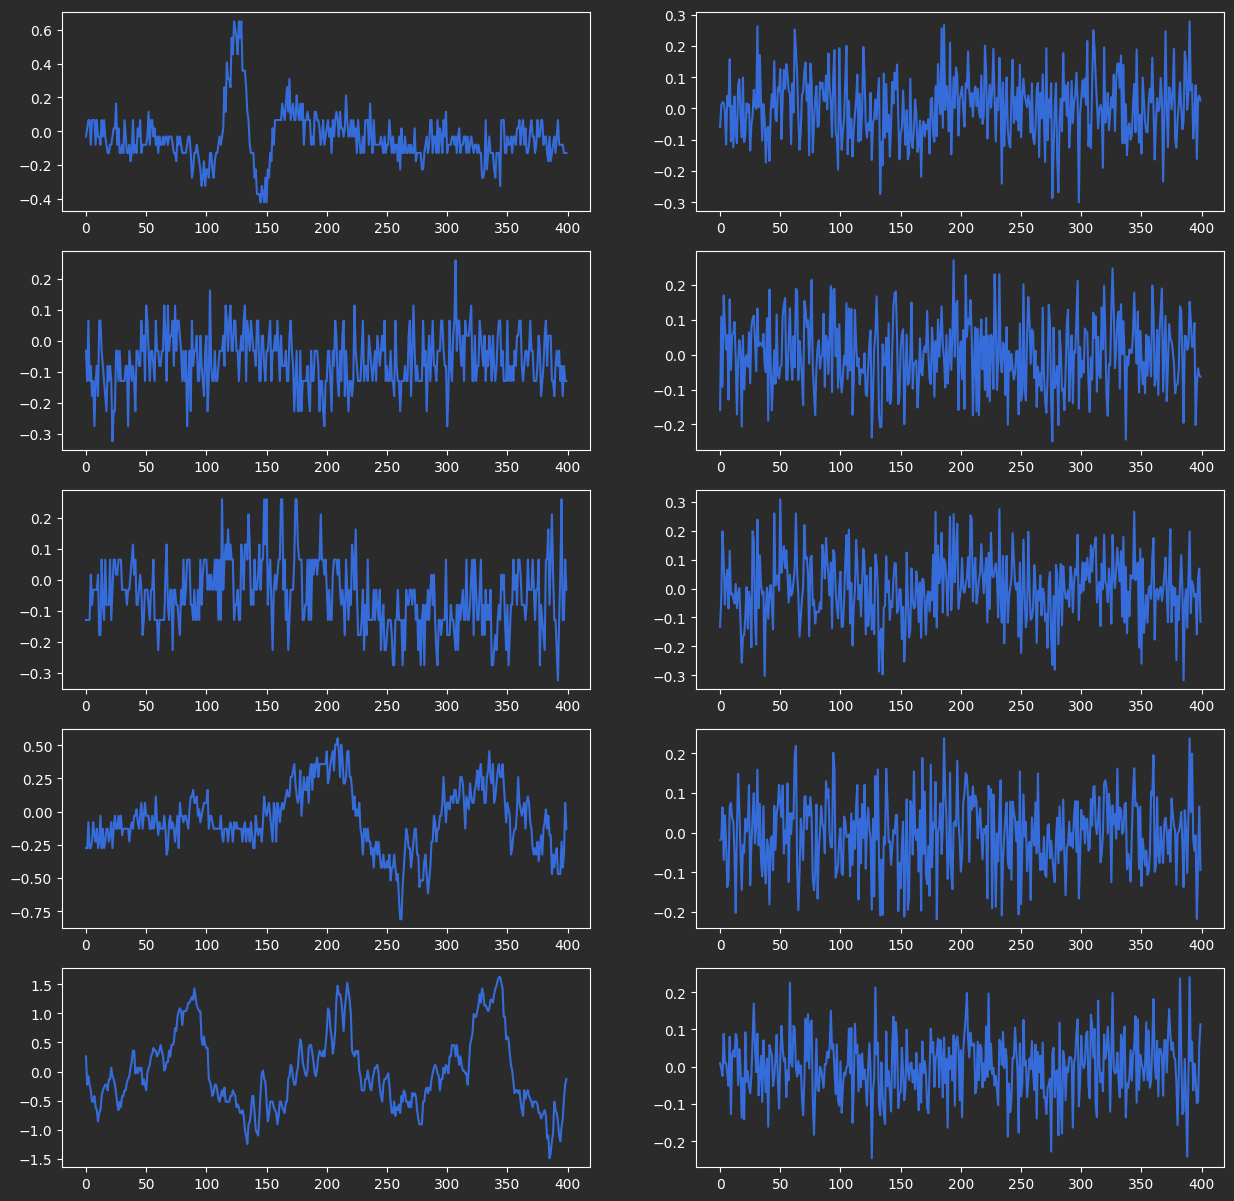

In [25]:

for windowed_data in all_reshaped_data:
        n,m,d = windowed_data.shape
        # print(windowed_data.shape)

        # safety check---------
        windowed_data = windowed_data[:, :MAX_POSSIBLE_WINDOWS, :]
        this_stage_loss = []
        for step in range(1):

            # verbose = True if (step + 1) % 3 == 0 else False
            verbose = True

            # -------------------- FORWARD PASS THROUGH THE NETWORK ------------
            x_amp = amplitude_layer_c(amplitude_layer_b(amplitude_layer_a(windowed_data)))
            x_freq = freq_fc_layer(freq_fft_layer(windowed_data))

            if verbose:
                print(f"amp shape:  {x_amp.shape} freq shape: {x_freq.shape}")
            stacked = stacking_layer(x_amp, x_freq)
            if verbose:
                print(f"stacked shape:  {stacked.shape}")
            x_stacked = rope_layer(stacked)
            if verbose:
                print(f"Rope shape:  {x_stacked.shape}")

            encoded = fc_c(fc_b(fc_a(dropout_a(enc_attention(x_stacked)))))
            if verbose:
                print("latent encoding is shape: ", encoded.shape)

            x_prime = decoder_fc_c(
                decoder_norm(
                    decoder_fc_b(
                        decoder_fc_a(
                            decoder_attention(
                                decoder_dropout(encoded))))
                )
            )
            break
        break

plt.figure(figsize=(15, 15))
print(windowed_data.shape, x_prime.shape)
for idx in range(1, 10, 2):
    plt.subplot(5,2, idx)
    plt.plot(windowed_data[:, idx, ...].reshape(-1))
    plt.subplot(5,2, idx + 1)
    plt.plot(x_prime[:, idx, ...].reshape(-1))

plt.show()